In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, recall_score, classification_report

In [37]:
df= pd.read_csv('C:/Users/Shreni/OneDrive/Desktop/AI-Product-Development/AIPD_Datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [38]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [40]:
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627  

In [41]:
print("Missing values before handling")
print(df.isnull().sum())
print("Shape:", df.shape)

Missing values before handling
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Shape: (768, 9)


In [42]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [43]:
print("Missing values after handling")
print(df.isnull().sum())
print("Shape:", df.shape)

Missing values after handling
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Shape: (768, 9)


In [44]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [45]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [46]:
print("Shape before outlier removal")
print(df.shape)

Shape before outlier removal
(768, 9)


In [47]:
def remove_outlier(df):
    df= df.copy()

    for col in df.select_dtypes(include=[np.number]).columns:
        q1= df[col].quantile(0.25)
        q3= df[col].quantile(0.75)
        iqr=q3-q1
        lower= q1-1.5*iqr
        upper= q3+1.5*iqr

        df= df[(df[col] >=lower) & (df[col]<=upper)]
    return df

df= remove_outlier(df)

In [48]:
print("Shape after outlier removal")
print(df.shape)

Shape after outlier removal
(636, 9)


In [49]:
x= df.drop(['Outcome'], axis=1)
y= df['Outcome']

In [50]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [51]:
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [52]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
rf_pred = rf.predict(x_test_scaled)
joblib.dump(rf, "rf.pkl")

['rf.pkl']

In [53]:
dt= DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled, y_train)
dt_pred= dt.predict(x_test_scaled)
joblib.dump(dt, "dt.pkl")

['dt.pkl']

In [54]:
lr= LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)
lr_pred= lr.predict(x_test_scaled)
joblib.dump(lr, "lr.pkl")

['lr.pkl']

In [55]:
def evaluate_model(model_name, y_test, y_pred):
    print(f"\n==========={model_name}=============")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix\n", confusion_matrix(y_test, y_pred))

In [56]:
evaluate_model("Random Forest", y_test, rf_pred)


===========Random Forest=============
Accuracy: 0.765625
Precision: 0.7555272108843538
Recall: 0.765625
F1 Score: 0.7551843317972351

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84        88
           1       0.67      0.50      0.57        40

    accuracy                           0.77       128
   macro avg       0.73      0.69      0.71       128
weighted avg       0.76      0.77      0.76       128


Confusion Matrix
 [[78 10]
 [20 20]]


In [57]:
evaluate_model("Logisctic Regression", y_test, lr_pred)


===========Logisctic Regression=============
Accuracy: 0.796875
Precision: 0.7903911564625851
Recall: 0.796875
F1 Score: 0.787826420890937

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86        88
           1       0.73      0.55      0.63        40

    accuracy                           0.80       128
   macro avg       0.77      0.73      0.74       128
weighted avg       0.79      0.80      0.79       128


Confusion Matrix
 [[80  8]
 [18 22]]


In [58]:
evaluate_model("Decision Tree", y_test, dt_pred)


===========Decision Tree=============
Accuracy: 0.6796875
Precision: 0.6692588325652842
Recall: 0.6796875
F1 Score: 0.6734346224677716

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77        88
           1       0.49      0.42      0.45        40

    accuracy                           0.68       128
   macro avg       0.62      0.61      0.61       128
weighted avg       0.67      0.68      0.67       128


Confusion Matrix
 [[70 18]
 [23 17]]


In [59]:
feature_importance= pd.DataFrame({
    "Feature": x.columns,
    "Importance":rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:", feature_importance)

Random Forest Feature Importance:                     Feature  Importance
1                   Glucose    0.257717
5                       BMI    0.146600
7                       Age    0.140978
6  DiabetesPedigreeFunction    0.123896
0               Pregnancies    0.100917
2             BloodPressure    0.085415
4                   Insulin    0.073083
3             SkinThickness    0.071393


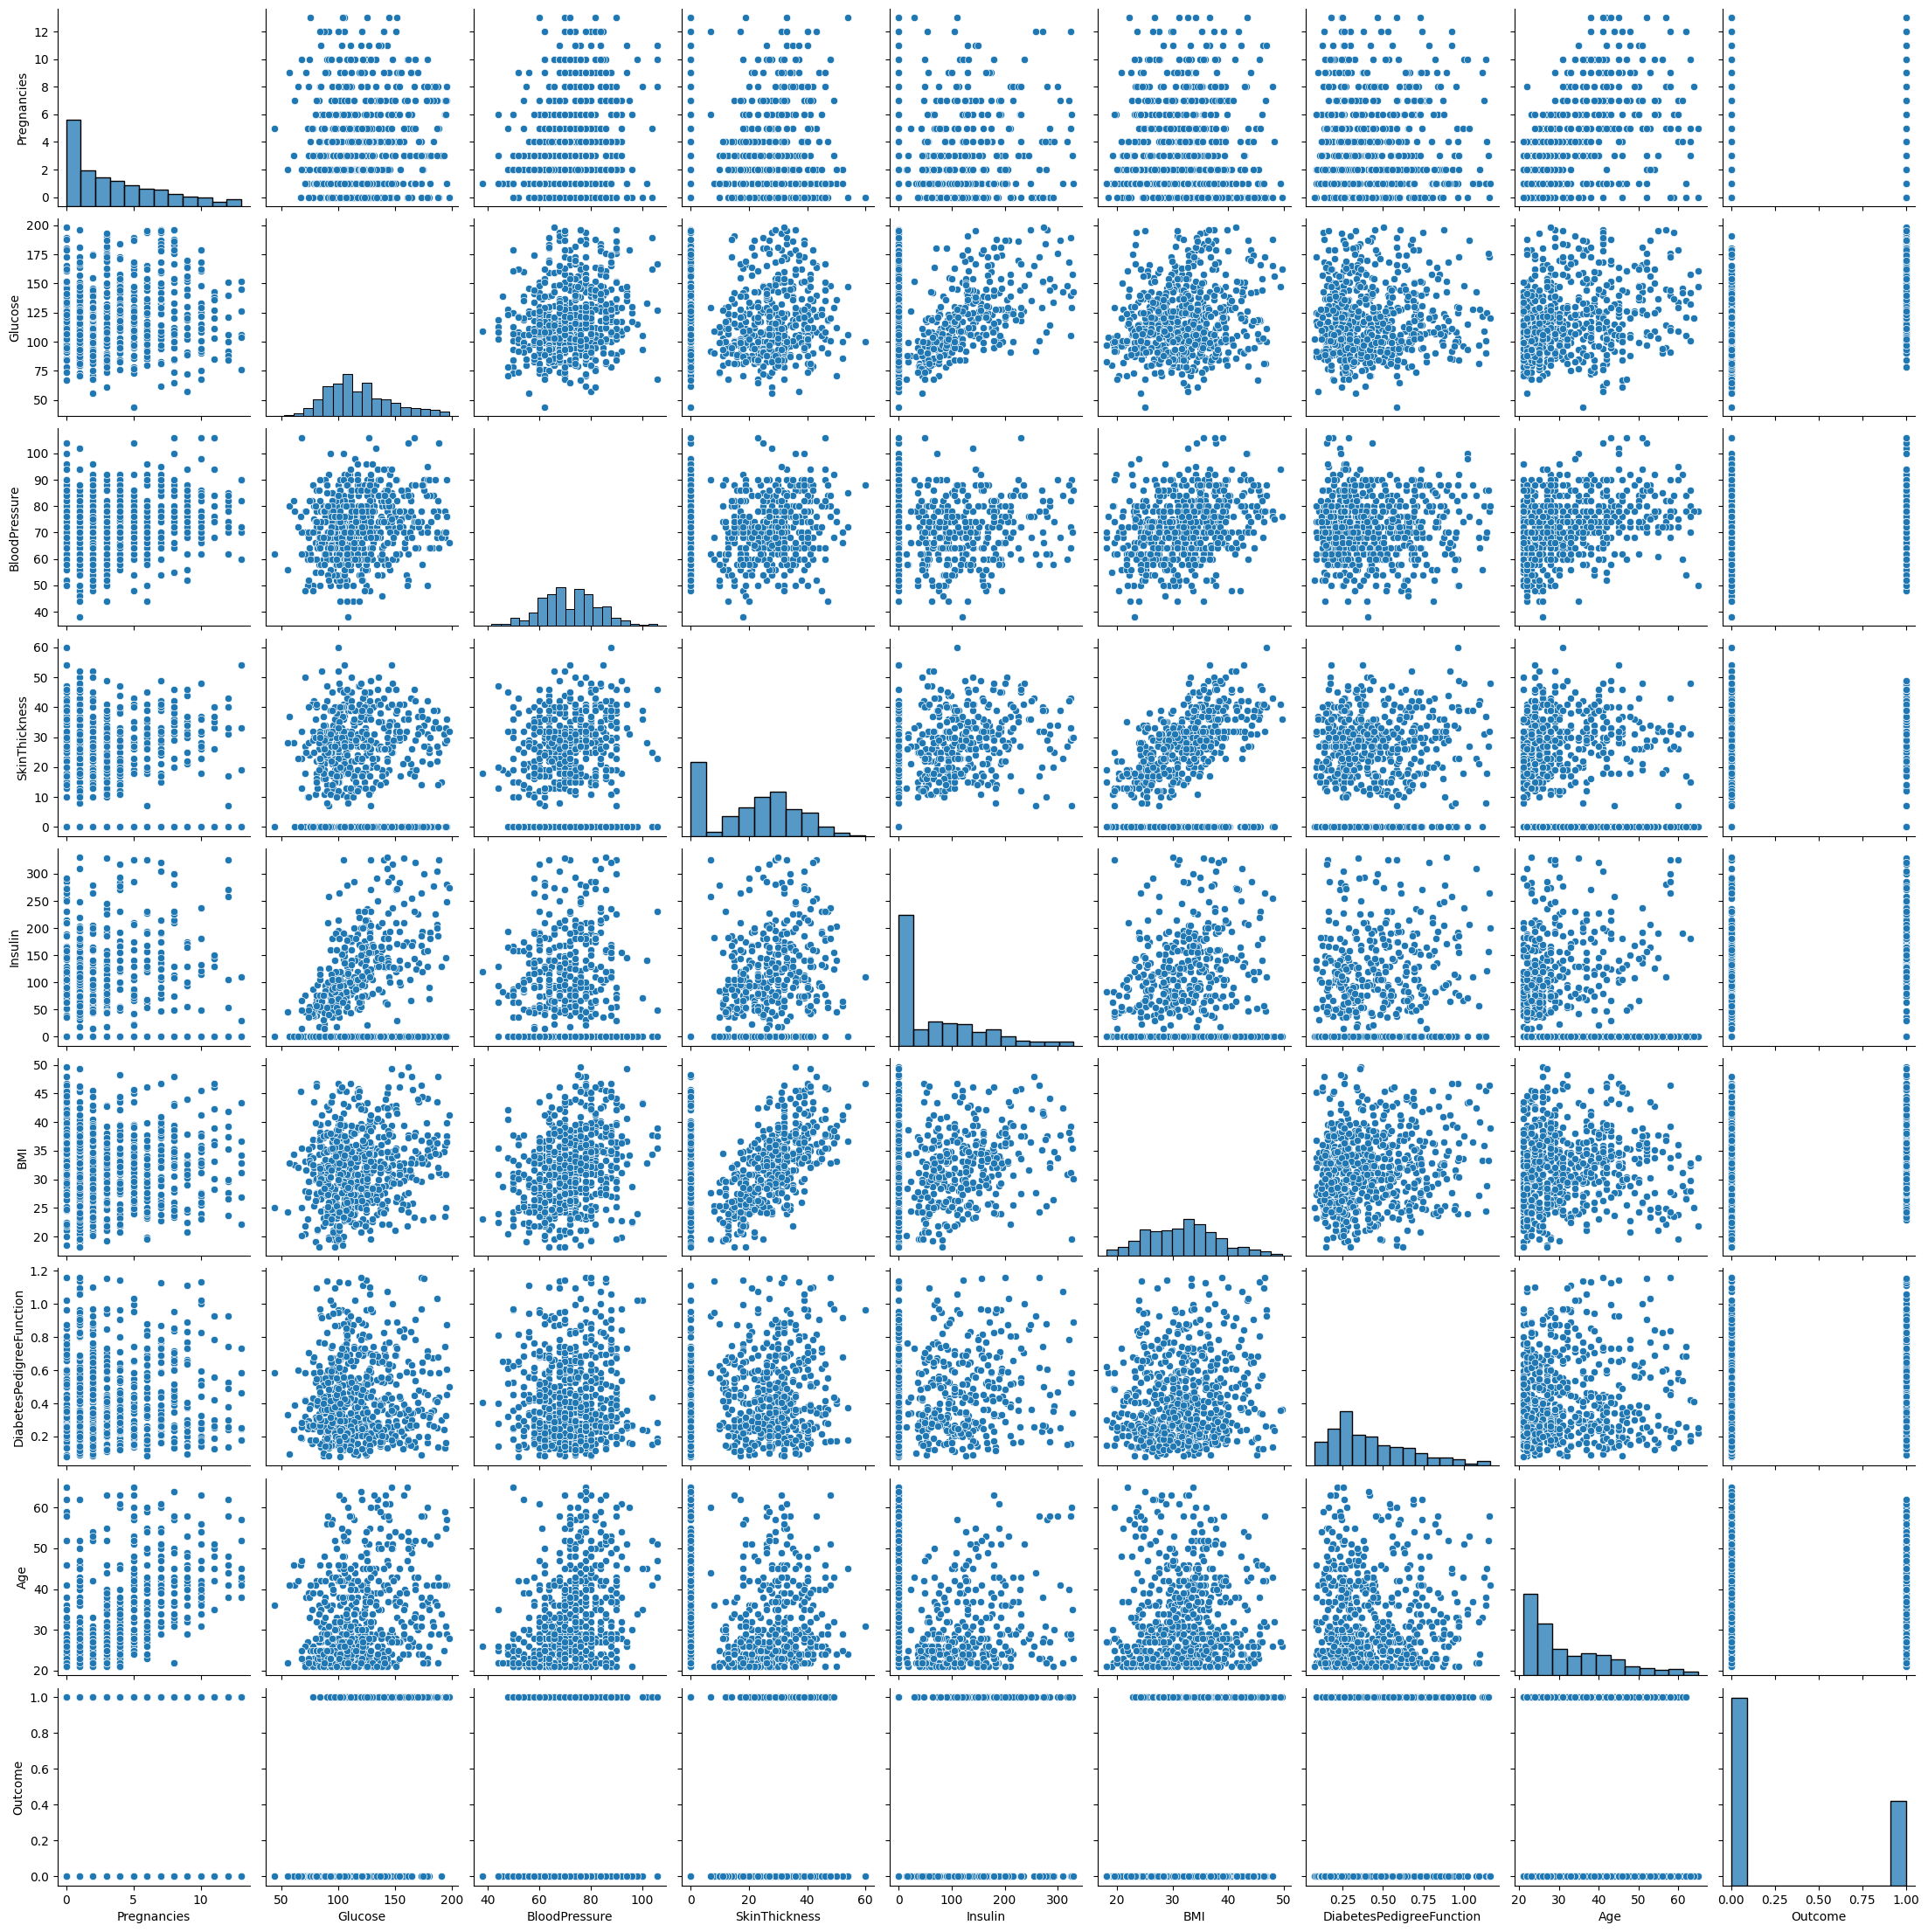

In [60]:
sns.pairplot(df)

<Axes: ylabel='Count'>

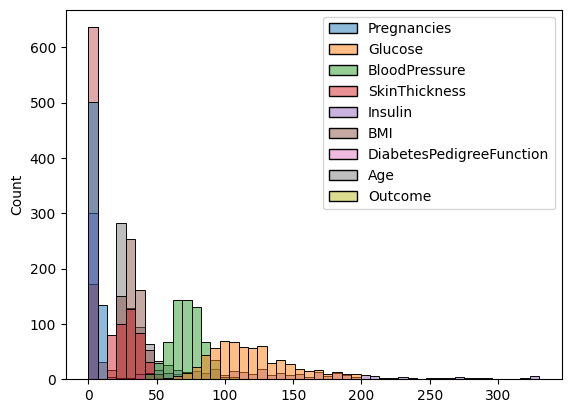

In [61]:
sns.histplot(df)

<Axes: >

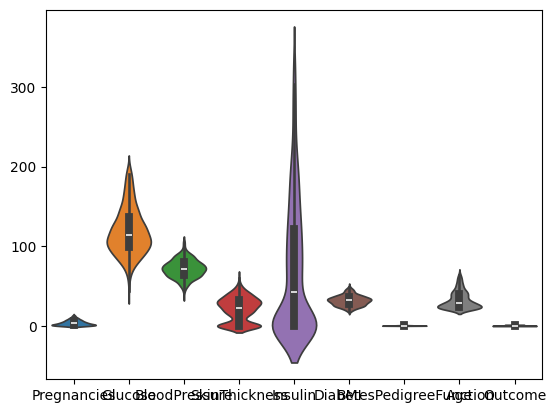

In [62]:
sns.violinplot(df)

<Axes: >

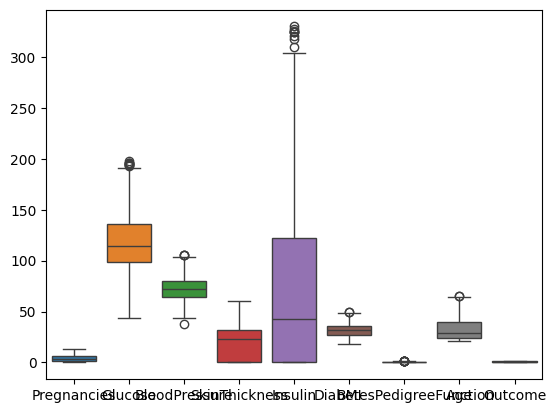

In [63]:
sns.boxplot(df)

<Axes: ylabel='Density'>

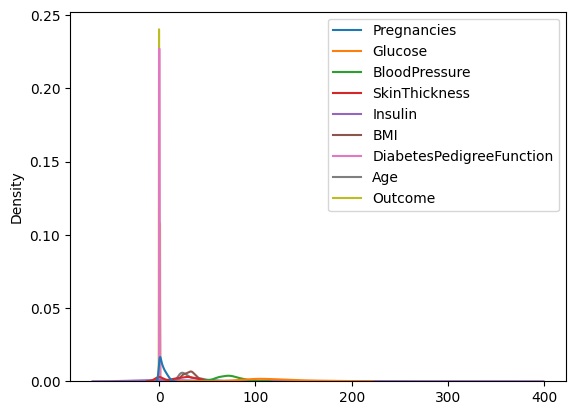

In [64]:
sns.kdeplot(df)